# 🏥 Medical Prescription AI Pipeline
### Medication extraction from prescriptions — Professional version

---

## 🧠 What this notebook does (read first)

This notebook **does not create or train a model**. It runs a processing pipeline on **your own prescription images**:

```
Your image
   ↓
[OCR]  → detects text regions + reads text (pretrained model)
   ↓
[Cleaning]  → normalizes raw text
   ↓
[RxNorm]  → corrects medication names (official database)
   ↓
[Ollama / llama3]  → extracts and structures JSON
   ↓
Final JSON: drug, dose, frequency, duration, remarks
```

**OCR** uses a pretrained deep learning model for inference.  
**RxNorm** is the official US drug database (NIH).  
**Ollama** runs llama3 locally on your machine.

---
⚠️ **No image is generated automatically** — you provide your own prescription in STEP 2.

## 🔧 STEP 0 — Install dependencies

Run this cell first. Installation takes 3-8 minutes depending on your connection.  
The OCR model downloads its weights (~50 MB) on first use.

In [61]:
# ============================================================
# STEP 0A — Installation
# ============================================================
import subprocess, sys

def pip_install(pkg):
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q"],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print(f"  ❌ Échec : {pkg}")
        print(result.stderr[-300:])
    else:
        print(f"  ✅ {pkg}")

packages = [
    "paddlepaddle",           # moteur PaddleOCR (CPU)
    "paddleocr>=2.7.0",       # OCR + détection de texte
    "rapidfuzz",              # fuzzy matching pour les noms de médicaments
    "matplotlib",
    "opencv-python-headless",
    "Pillow",
    "requests",
    "numpy",
    "pandas",                 # lecture des datasets de médicaments
    "tqdm",                   # barre de progression
]

print("📦 Installation en cours...")
for pkg in packages:
    pip_install(pkg)
print("\n✅ Installation terminée.")

📦 Installation en cours...
  ✅ paddlepaddle
  ✅ paddleocr>=2.7.0
  ✅ rapidfuzz
  ✅ matplotlib
  ✅ opencv-python-headless
  ✅ Pillow
  ✅ requests
  ✅ numpy
  ✅ pandas
  ✅ tqdm

✅ Installation terminée.


In [62]:
import os
import re
import json
import time
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageDraw
import cv2
from tqdm import tqdm
from rapidfuzz import process as fuzz_process, fuzz

warnings.filterwarnings('ignore')

# EasyOCR — alternative moderne à PaddleOCR (compatible Python 3.13)
import easyocr
print("✅ EasyOCR importé")

print("✅ Tous les imports OK")

✅ EasyOCR importé
✅ Tous les imports OK


## 💊 STEP 1 — Load medication database

We download the official database:

| Database | Source | Language | Content |
|------|--------|--------|---------|
| **RxNorm** | NIH (USA) | English | ~100,000 drug names |

This database is used to **correct OCR errors** in medication names.

In [63]:
# ============================================================
# STEP 1 — Chargement de la base de données officielle
# ============================================================

# ──────────────────────────────────────────────────────────
# BASE : RxNorm (NIH)
# API publique, aucune clé requise
# Endpoint : retourne les noms de médicaments approuvés
# ──────────────────────────────────────────────────────────
def load_rxnorm_names(max_names=8000):
    """
    Charge les noms de médicaments depuis l'API RxNorm (NIH).
    On utilise le endpoint /allconcepts qui retourne les concepts actifs.
    """
    print("🔄 Chargement RxNorm (NIH)...")
    names = set()

    try:
        # RxNorm API : liste de tous les identifiants actifs
        url = "https://rxnav.nlm.nih.gov/REST/allconcepts.json?tty=IN+PIN+BN+SCDC+SBD"
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        data = resp.json()

        concepts = data.get("minConceptGroup", {}).get("minConcept", [])
        for c in concepts[:max_names]:
            name = c.get("name", "").strip()
            if name and len(name) >= 3:
                # Garder seulement la partie avant la première parenthèse
                # ex : "Amoxicillin 500 MG Oral Capsule" → "Amoxicillin 500 MG Oral Capsule"
                # On extrait aussi le premier mot (DCI)
                names.add(name)
                first_word = name.split()[0]
                if len(first_word) >= 4:
                    names.add(first_word)

        print(f"  ✅ RxNorm : {len(names):,} entrées chargées")

    except requests.exceptions.RequestException as e:
        print(f"  ⚠️  RxNorm API inaccessible ({e})")
        print("     → Tentative de chargement du fichier local si disponible...")
        # Fallback : liste minimale pour ne pas bloquer le pipeline
        names = {
            "Amoxicillin","Paracetamol","Ibuprofen","Omeprazole","Metformin",
            "Atorvastatin","Amlodipine","Lisinopril","Metoprolol","Aspirin",
            "Ciprofloxacin","Azithromycin","Doxycycline","Tramadol","Codeine"
        }
        print(f"  ⚠️  Fallback RxNorm : {len(names)} entrées")

    return list(names)


# ──────────────────────────────────────────────────────────
# Chargement de la base
# ──────────────────────────────────────────────────────────
rxnorm_names = load_rxnorm_names()

# Suppression doublons + filtrage
DRUG_DATABASE = list(set(rxnorm_names))
# Garder uniquement les noms de longueur utile (éviter trop de bruit)
DRUG_DATABASE = [d for d in DRUG_DATABASE if 4 <= len(d) <= 80]

print(f"\n📊 Base RxNorm : {len(DRUG_DATABASE):,} noms de médicaments")
print(f"   Exemple d'entrées : {DRUG_DATABASE[:8]}")

🔄 Chargement RxNorm (NIH)...
  ✅ RxNorm : 9,250 entrées chargées

📊 Base RxNorm : 9,219 noms de médicaments
   Exemple d'entrées : ['amyl salicylate', 'ReadyBath', '2-(4-(diethylamino)-2-hydroxybenzoyl)benzoic acid', 'Tulissin', 'Zyclara', 'Alophen', '4-hydroxycyclophosphamide', 'annatto extract']


## 🖼️ STEP 2 — Load your prescription image

**⚠️ You must provide your own image here.**

- On **Google Colab**: uncomment the `files.upload()` block
- On **Kaggle**: upload via *Add Data* and set the path
- **Locally**: set the absolute path

✅ Image chargée : ordonnance.png
   Dimensions : 912 × 1025 pixels
   Mode       : RGB


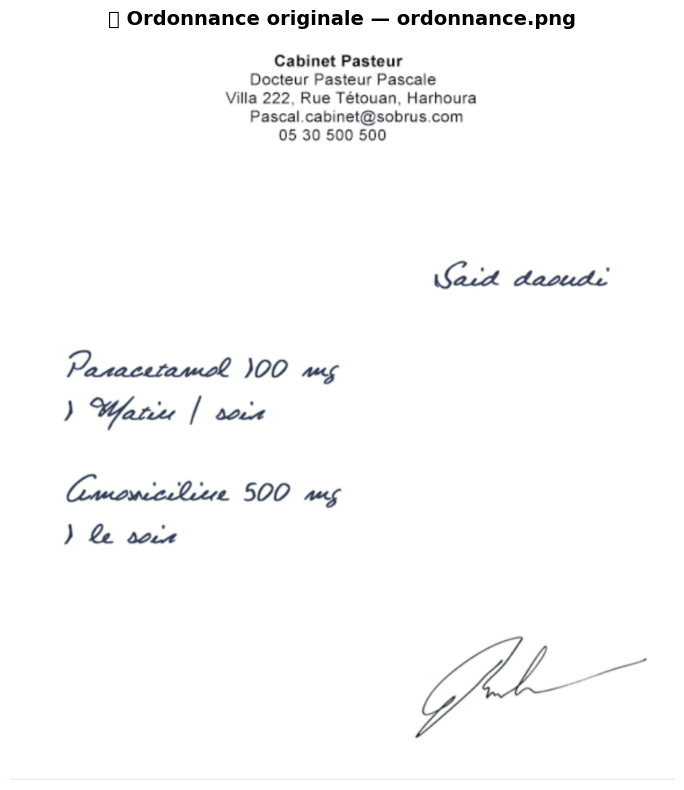

In [64]:
# ============================================================
# STEP 2 — Import de l'image
# ============================================================

# ── Option A : Google Colab ────────────────────────────────
# from google.colab import files
# uploaded = files.upload()
# IMAGE_PATH = list(uploaded.keys())[0]

# ── Option B : Kaggle ──────────────────────────────────────
# IMAGE_PATH = "/kaggle/input/TON_DATASET/prescription.jpg"

# ── Option C : Chemin local ────────────────────────────────
IMAGE_PATH = "ordonnance.png"   # ← MODIFIE CE CHEMIN

# ──────────────────────────────────────────────────────────
# Vérification
# ──────────────────────────────────────────────────────────
if not os.path.exists(IMAGE_PATH):
    raise FileNotFoundError(
        f"\n❌ Image non trouvée : {IMAGE_PATH}\n"
        "   → Modifie IMAGE_PATH avec le chemin correct vers ton ordonnance."
    )

# Chargement et affichage
img_pil   = Image.open(IMAGE_PATH).convert("RGB")
img_array = np.array(img_pil)

print(f"✅ Image chargée : {IMAGE_PATH}")
print(f"   Dimensions : {img_pil.size[0]} × {img_pil.size[1]} pixels")
print(f"   Mode       : {img_pil.mode}")

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(img_array)
ax.set_title(f"📋 Ordonnance originale — {os.path.basename(IMAGE_PATH)}",
             fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 🔍 STEP 3 — Text region detection (OCR)

Here we use **EasyOCR** for detection + recognition (you can swap in PaddleOCR if needed).

EasyOCR runs entirely on CPU by default in this notebook (`gpu=False`).

⚠️ The first run downloads model weights (~100 MB). Subsequent runs are instant.

Using CPU. Note: This module is much faster with a GPU.


🔄 Initialisation d'EasyOCR...
   (Premier lancement : téléchargement des modèles ~100 MB)
✅ EasyOCR prêt

🔍 Analyse de l'image en cours...
✅ Analyse terminée en 2.8s

📦 20 zones de texte détectées


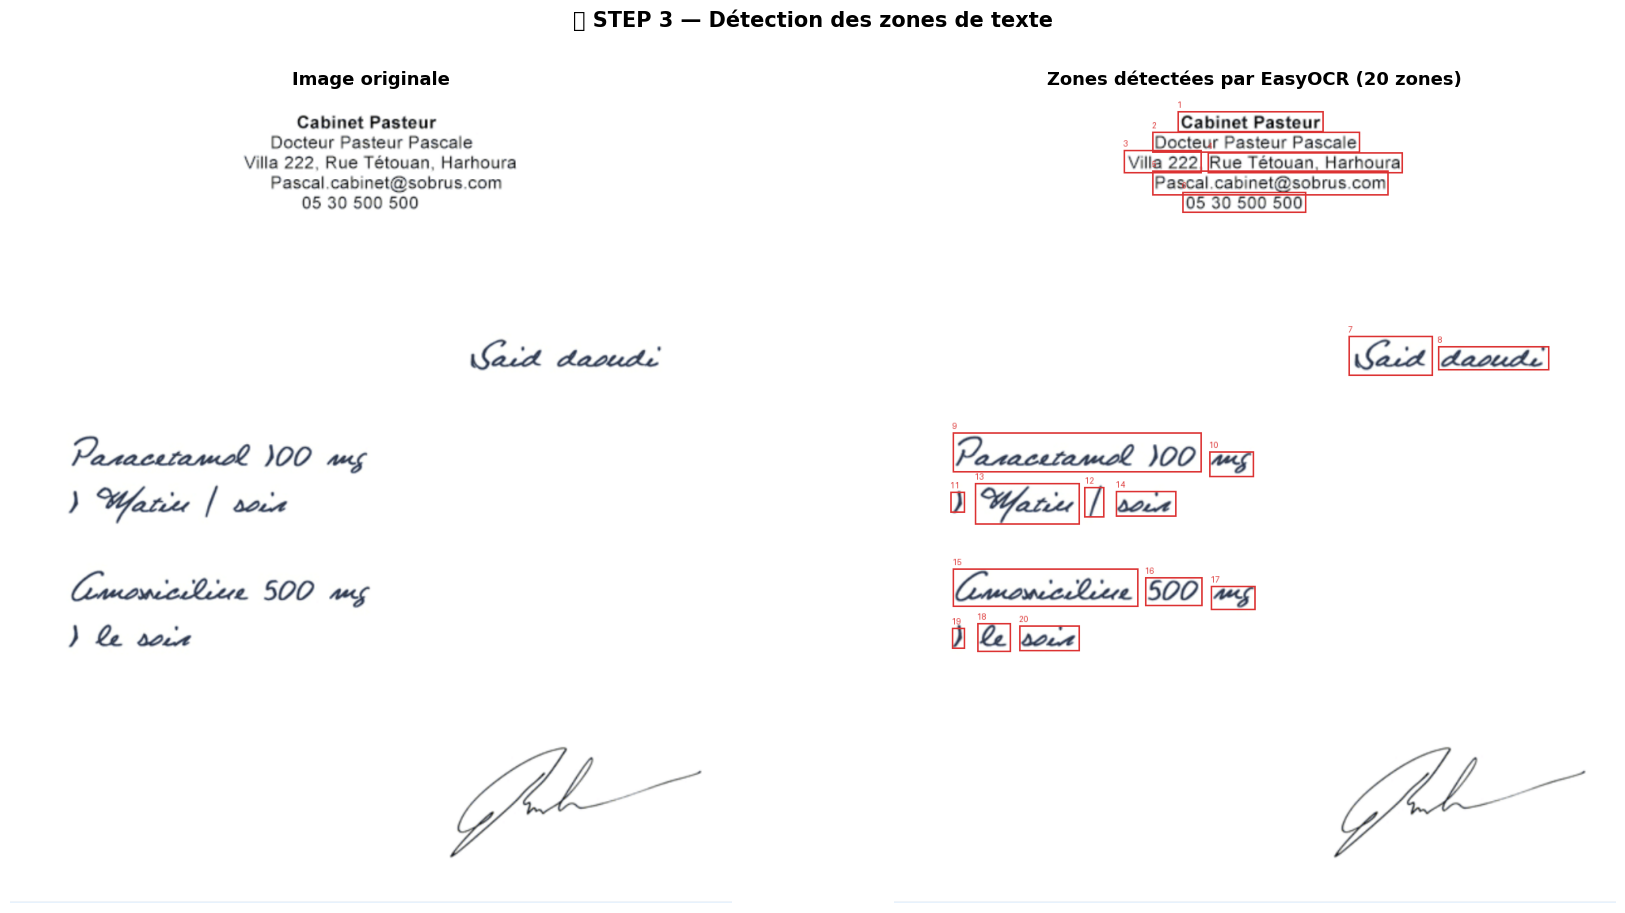

In [65]:
# ============================================================
# STEP 3 — Initialisation EasyOCR et détection des zones
# ============================================================

print("🔄 Initialisation d'EasyOCR...")
print("   (Premier lancement : téléchargement des modèles ~100 MB)")

# EasyOCR Reader pour français + anglais
reader = easyocr.Reader(['fr', 'en'], gpu=False)

print("✅ EasyOCR prêt")

# ── Lancement de la détection + reconnaissance ──
print("\n🔍 Analyse de l'image en cours...")
t0 = time.time()

ocr_results = reader.readtext(IMAGE_PATH)

elapsed = time.time() - t0
print(f"✅ Analyse terminée en {elapsed:.1f}s")

# ── Extraction des boîtes et du texte depuis le résultat ──
# Structure d'EasyOCR : liste de tuples (bbox, texte, confiance)
# bbox est un list de 4 points [[x1,y1], [x2,y2], [x3,y3], [x4,y4]]

ocr_lines = []
for detection in ocr_results:
    bbox = detection[0]
    text = detection[1]
    confidence = detection[2]
    # Calculer le centre Y pour trier par position
    y_center = np.mean([p[1] for p in bbox])
    ocr_lines.append({
        'bbox': bbox,
        'text': text,
        'confidence': confidence,
        'y_center': y_center
    })

if not ocr_lines:
    raise RuntimeError(
        "❌ EasyOCR n'a détecté aucun texte dans l'image.\n"
        "   Vérifie la qualité de l'image et le chemin IMAGE_PATH."
    )

# Trier de haut en bas
ocr_lines.sort(key=lambda x: x['y_center'])

print(f"\n📦 {len(ocr_lines)} zones de texte détectées")

# Créer raw_text pour les étapes suivantes
raw_text = "\n".join([l['text'] for l in ocr_lines])

# ── Affichage avec boîtes englobantes ──
img_annotated = img_pil.copy()
draw = ImageDraw.Draw(img_annotated)

for i, line in enumerate(ocr_lines):
    pts = line['bbox']
    # Convertir en rectangle simple [x1, y1, x2, y2]
    x1 = min(p[0] for p in pts)
    y1 = min(p[1] for p in pts)
    x2 = max(p[0] for p in pts)
    y2 = max(p[1] for p in pts)
    draw.rectangle([x1, y1, x2, y2], outline=(220, 50, 50), width=2)
    # Numéro de ligne
    draw.text((x1, max(0, y1 - 14)), str(i + 1), fill=(220, 50, 50))

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
axes[0].imshow(img_array)
axes[0].set_title("Image originale", fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(np.array(img_annotated))
axes[1].set_title(f"Zones détectées par EasyOCR ({len(ocr_lines)} zones)",
                  fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.suptitle("🔍 STEP 3 — Détection des zones de texte",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 🧭 STEP 3B — Grad-CAM-style OCR explanation (EasyOCR)

This optional step builds a **Grad-CAM-style heatmap** from EasyOCR detections to explain which regions contributed to OCR results.  
It is a **diagnostic view** and is not used by the OCR pipeline itself.  
If EasyOCR is not available, the cell will skip without errors.

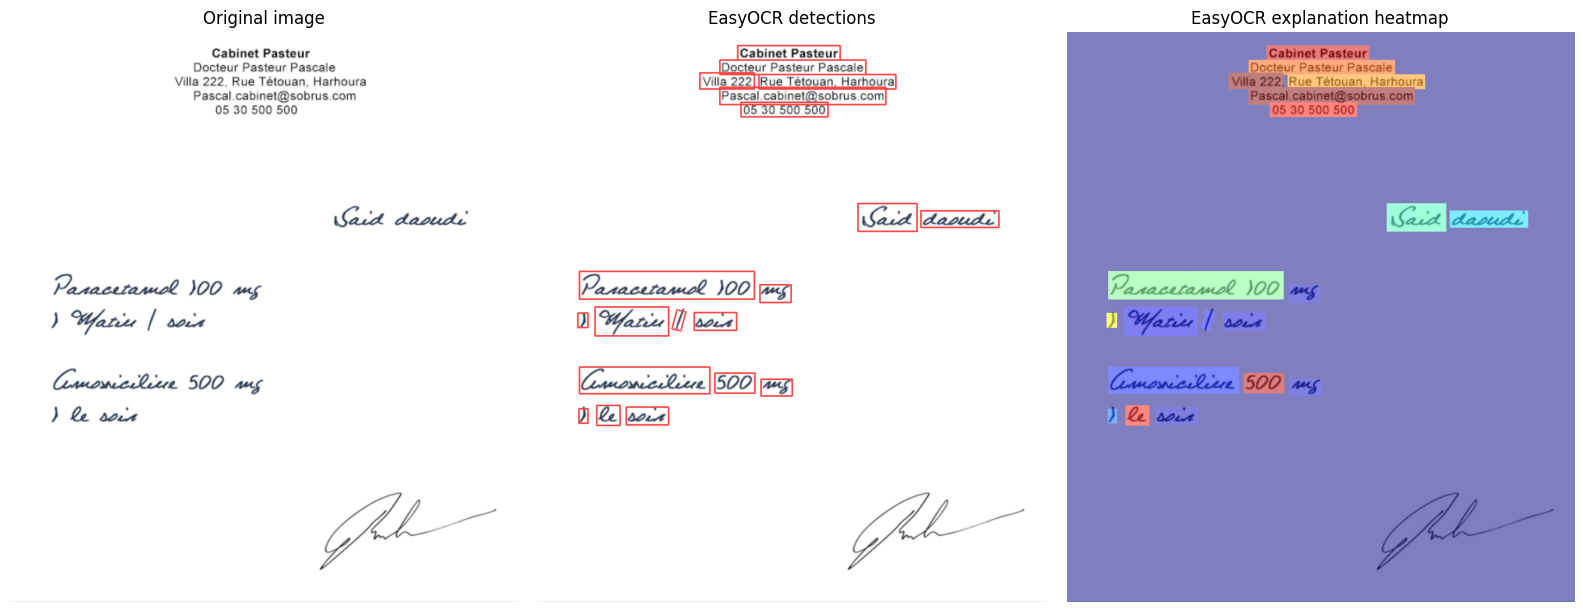

In [66]:
# ============================================================
# STEP 3B — Grad-CAM-style OCR explanation (EasyOCR)
# ============================================================

def _easyocr_available():
    try:
        import easyocr  # noqa: F401
        return True
    except Exception:
        return False

if not _easyocr_available():
    print("⚠️ EasyOCR not available: skipping OCR explanation heatmap.")
else:
    try:
        import numpy as np
        import cv2
        import matplotlib.pyplot as plt
        from PIL import Image
        import easyocr

        # Use existing OCR results if available, otherwise run EasyOCR
        if 'ocr_results' in globals() and isinstance(ocr_results, list) and ocr_results:
            results = ocr_results
        else:
            reader_local = easyocr.Reader(['fr', 'en'], gpu=False)
            results = reader_local.readtext(IMAGE_PATH)

        # Build a confidence heatmap from detected boxes
        img = Image.open(IMAGE_PATH).convert("RGB")
        img_np = np.array(img)
        h, w = img_np.shape[:2]
        heat = np.zeros((h, w), dtype=np.float32)

        for det in results:
            if not det or len(det) < 3:
                continue
            box, _, conf = det[0], det[1], det[2]
            pts = np.array(box, dtype=np.int32)
            cv2.fillPoly(heat, [pts], float(conf))

        heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)
        heatmap = cv2.applyColorMap((heat * 255).astype(np.uint8), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        overlay = (0.5 * img_np + 0.5 * heatmap).astype(np.uint8)

        # Draw boxes for reference
        boxed = img_np.copy()
        for det in results:
            if not det:
                continue
            box = np.array(det[0], dtype=np.int32)
            cv2.polylines(boxed, [box], isClosed=True, color=(255, 70, 70), thickness=2)

        fig, ax = plt.subplots(1, 3, figsize=(16, 6))
        ax[0].imshow(img_np)
        ax[0].set_title("Original image")
        ax[0].axis("off")
        ax[1].imshow(boxed)
        ax[1].set_title("EasyOCR detections")
        ax[1].axis("off")
        ax[2].imshow(overlay)
        ax[2].set_title("EasyOCR explanation heatmap")
        ax[2].axis("off")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"❌ EasyOCR Grad-CAM-style step failed: {e}")

## 📝 STEP 4 — OCR text extraction

**Why does OCR make mistakes on prescriptions?**
- Drug names are long and uncommon in training corpora
- Characters like `l`/`1`, `O`/`0`, `rn`/`m`, `I`/`l` are visually similar
- Scan quality or handwriting reduces signal

That is why fuzzy matching against RxNorm is needed.

In [67]:
# ============================================================
# STEP 4 — Extraction du texte OCR
# ============================================================

# ocr_lines est déjà créé par STEP 3 avec la structure :
# [{'text': ..., 'confidence': ..., 'bbox': ..., 'y_center': ...}, ...]

# ── Affichage table ──
print("="*72)
print("  📝 SORTIE OCR BRUTE — EasyOCR")
print("="*72)
print(f"  {'#':<4}  {'Texte extrait':<44}  {'Confiance':>9}")
print("-"*72)
for i, l in enumerate(ocr_lines):
    conf = l['confidence']
    flag = "🟢" if conf >= 0.90 else ("🟡" if conf >= 0.70 else "🔴")
    print(f"  {i+1:<4}  {l['text'][:43]:<44}  {flag} {conf:>6.1%}")
print("="*72)
avg = np.mean([l['confidence'] for l in ocr_lines])
low = sum(1 for l in ocr_lines if l['confidence'] < 0.70)
print(f"  Confiance moyenne : {avg:.1%}   |   Lignes à faible confiance : {low}")
print("="*72)

# raw_text est déjà créé par STEP 3
print(f"\n📄 Texte brut complet ({len(raw_text)} caractères) :")
print(raw_text)

  📝 SORTIE OCR BRUTE — EasyOCR
  #     Texte extrait                                 Confiance
------------------------------------------------------------------------
  1     Cabinet Pasteur                               🟢  92.3%
  2     Docteur Pasteur Pascale                       🟡  78.9%
  3     Villa 222                                     🟢 100.0%
  4     Rue Tétouan, Harhoura                         🟡  73.5%
  5     Pascal cabinet@sobrus com                     🟢  99.8%
  6     05 30 500 500                                 🟡  86.9%
  7     Saia                                          🔴  44.3%
  8     dapud                                         🔴  34.2%
  9     ParacetamoQ )oo                               🔴  49.8%
  10    A                                             🔴   7.4%
  11    )                                             🔴  62.9%
  12    1                                             🔴  13.0%
  13    9azie                                         🔴  10.3%
  14    Ja1  

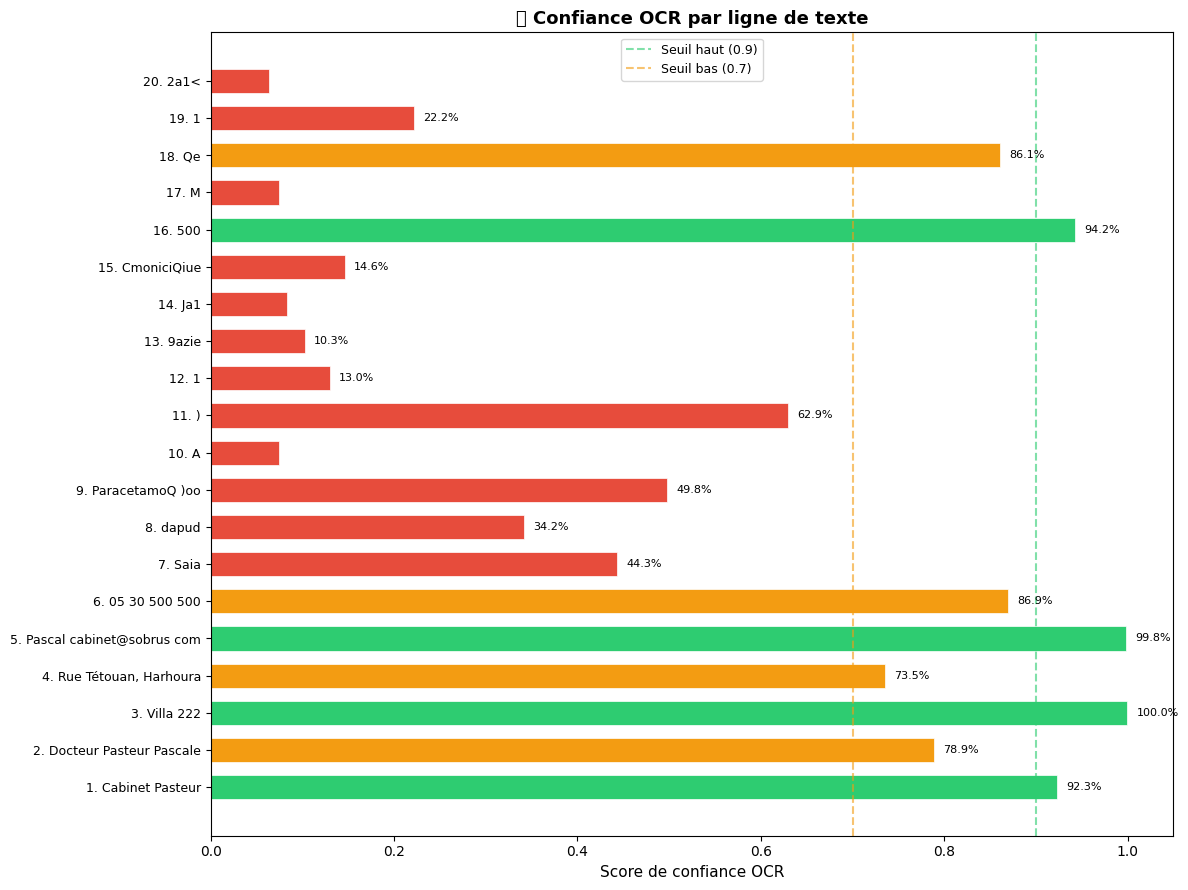

In [68]:
# ── Visualisation de la confiance par ligne (graphique) ──
labels = [f"{i+1}. {l['text'][:30]}" for i, l in enumerate(ocr_lines)]
scores = [l['confidence'] for l in ocr_lines]
colors = ['#2ecc71' if s >= 0.9 else ('#f39c12' if s >= 0.70 else '#e74c3c') for s in scores]

fig, ax = plt.subplots(figsize=(12, max(4, len(ocr_lines) * 0.45)))
bars = ax.barh(range(len(labels)), scores, color=colors, height=0.65, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlim(0, 1.05)
ax.set_xlabel("Score de confiance OCR", fontsize=11)
ax.set_title("📊 Confiance OCR par ligne de texte", fontsize=13, fontweight='bold')
ax.axvline(x=0.9, color='#2ecc71', linestyle='--', alpha=0.6, label='Seuil haut (0.9)')
ax.axvline(x=0.7, color='#f39c12', linestyle='--', alpha=0.6, label='Seuil bas (0.7)')
ax.legend(fontsize=9)

# Afficher la valeur sur chaque barre
for i, (bar, score) in enumerate(zip(bars, scores)):
    ax.text(score + 0.01, i, f'{score:.1%}', va='center', fontsize=8,
            color='black' if score > 0.1 else 'white')

plt.tight_layout()
plt.show()

## 🧹 STEP 5 — Text cleaning and normalization

We remove noise: special characters, repeated spaces, empty lines, boilerplate.  
We keep only useful medical information.

In [69]:
# ============================================================
# STEP 5 — Nettoyage du texte OCR
# ============================================================

def clean_ocr_text(text):
    """
    Nettoie et normalise la sortie OCR brute.

    Opérations :
        1. Suppression des emojis et symboles unicode non-ASCII
        2. Normalisation des espaces multiples
        3. Suppression des lignes trop courtes (bruit)
        4. Suppression des lignes purement numériques (numéros de page, etc.)
        5. Normalisation des séparateurs de lignes
    """
    # 1. Supprimer les caractères non-ASCII (emojis, symboles)
    text = re.sub(r'[^\x00-\x7F\u00C0-\u024F]+', ' ', text)

    lines = text.split('\n')
    cleaned_lines = []

    for line in lines:
        # 2. Normaliser les espaces
        line = re.sub(r'[ \t]+', ' ', line).strip()

        # 3. Ignorer les lignes trop courtes
        if len(line) < 3:
            continue

        # 4. Ignorer les lignes purement numériques
        if re.fullmatch(r'[\d\s\.\-\/]+', line):
            continue

        cleaned_lines.append(line)

    return '\n'.join(cleaned_lines)


cleaned_text = clean_ocr_text(raw_text)

# ── Affichage avant / après ──
print("="*76)
print("  🧹 NETTOYAGE — Avant vs Après")
print("="*76)
raw_lines     = [l for l in raw_text.split('\n') if l.strip()]
cleaned_lines = [l for l in cleaned_text.split('\n') if l.strip()]
print(f"  {'AVANT (brut OCR)':<36}  │  {'APRÈS (nettoyé)':<36}")
print("-"*76)
max_len = max(len(raw_lines), len(cleaned_lines))
for i in range(max_len):
    left  = raw_lines[i][:35]     if i < len(raw_lines)     else ""
    right = cleaned_lines[i][:35] if i < len(cleaned_lines) else ""
    print(f"  {left:<36}  │  {right:<36}")
print("="*76)
print(f"  Lignes avant : {len(raw_lines)}  →  Après : {len(cleaned_lines)}  "
      f"({len(raw_lines)-len(cleaned_lines)} lignes de bruit supprimées)")
print("="*76)

  🧹 NETTOYAGE — Avant vs Après
  AVANT (brut OCR)                      │  APRÈS (nettoyé)                     
----------------------------------------------------------------------------
  Cabinet Pasteur                       │  Cabinet Pasteur                     
  Docteur Pasteur Pascale               │  Docteur Pasteur Pascale             
  Villa 222                             │  Villa 222                           
  Rue Tétouan, Harhoura                 │  Rue Tétouan, Harhoura               
  Pascal cabinet@sobrus com             │  Pascal cabinet@sobrus com           
  05 30 500 500                         │  Saia                                
  Saia                                  │  dapud                               
  dapud                                 │  ParacetamoQ )oo                     
  ParacetamoQ )oo                       │  9azie                               
  A                                     │  Ja1                                 
  )         

## 🤖 STEP 6 — Structured extraction via LLM (Ollama / llama3)

**Why use an LLM after OCR + cleaning?**  
OCR yields raw text; cleaning removes noise, but the text is still **unstructured**.  
The LLM understands context: it knows `500mg` after `Amoxicillin` is a dose and `3x/day` is a frequency, etc.

RxNorm correction is applied in the next step on the medication names returned by the LLM.

**Ollama** runs llama3 locally — no data is sent to the cloud.

> ⚠️ **Prerequisites:** `ollama serve` must be running in a terminal and `ollama pull llama3` must have been executed.  
> If Ollama is missing, the notebook prints a clear message and does not fail.

In [70]:
# ============================================================
# STEP 6 — Appel Ollama (llama3 local)
# ============================================================

OLLAMA_URL = "http://localhost:11434"
OLLAMA_MODEL = "llama3:8b"


def check_ollama_status():
    """Vérifie si Ollama est actif et si llama3 est disponible."""
    try:
        resp = requests.get("http://localhost:11434/api/tags", timeout=5)
        models = [m['name'] for m in resp.json().get('models', [])]
        llama3_ok = any('llama3' in m for m in models)
        return True, llama3_ok, models
    except:
        return False, False, []


def build_prompt(text):
    """
    Prompt d'extraction structurée.
    On demande UNIQUEMENT du JSON — aucun texte autour.
    """
    return f"""You are a clinical pharmacist AI. Extract all medications and any non-medication remarks from this prescription text.
Return ONLY valid JSON. No explanation. No markdown. No extra text.

Required JSON schema:
{{
  "patient":    "patient name or null",
  "prescriber": "doctor name or null",
  "date":       "date in YYYY-MM-DD or null",
  "remarks":    "non-medication notes for the patient or null",
  "medications": [
    {{
      "name":         "official drug name",
      "dose":         "dose with unit (e.g. 500mg, 1g)",
      "frequency":    "how often (e.g. 3x/day, twice daily, every 8h)",
      "duration":     "duration (e.g. 7 days) or null",
      "route":        "route of administration (oral, IV, etc.) or null",
      "instructions": "special instructions or null"
    }}
  ]
}}

Prescription text:
---
{text}
---
JSON:"""


def call_ollama(text, model=OLLAMA_MODEL, timeout=90):
    """
    Envoie le texte à Ollama et retourne la réponse JSON.
    Gère proprement les erreurs de connexion.
    """
    payload = {
        "model" : model,
        "prompt": build_prompt(text),
        "stream": False,
        "options": {
            "temperature": 0.1,   # faible température = sorties plus déterministes
            "num_predict": 800
        }
    }
    resp = requests.post(OLLAMA_URL + "/api/generate", json=payload, timeout=timeout)
    resp.raise_for_status()
    return resp.json().get("response", "")


# ── Vérification Ollama ──────────────────────────────────────
ollama_running, llama3_available, available_models = check_ollama_status()

print("🤖 Statut Ollama :")
print(f"   Serveur actif  : {'✅ Oui' if ollama_running else '❌ Non — lance: ollama serve'}")
print(f"   llama3 présent : {'✅ Oui' if llama3_available else '❌ Non — lance: ollama pull llama3'}")
if available_models:
    print(f"   Modèles dispo  : {available_models}")

# ── Appel LLM ───────────────────────────────────────────────
llm_response_raw = None
llm_source       = None

if ollama_running and llama3_available:
    print("\n🔄 Envoi du texte à llama3...")
    try:
        t0 = time.time()
        llm_response_raw = call_ollama(cleaned_text)
        elapsed = time.time() - t0
        llm_source = "ollama/llama3"
        print(f"✅ Réponse reçue en {elapsed:.1f}s")
    except Exception as e:
        print(f"❌ Erreur lors de l'appel Ollama : {e}")
        llm_response_raw = None
else:
    print("\n⚠️  Ollama non disponible.")
    print("   Pour l'activer :")
    print("   1. Télécharger : https://ollama.com/download")
    print("   2. Terminal    : ollama serve")
    print("   3. Terminal    : ollama pull llama3")
    print("   4. Relancer cette cellule")

if llm_response_raw:
    print(f"\n--- Réponse brute LLM ({llm_source}) ---")
    print(llm_response_raw)

🤖 Statut Ollama :
   Serveur actif  : ✅ Oui
   llama3 présent : ✅ Oui
   Modèles dispo  : ['llama3:8b']

🔄 Envoi du texte à llama3...
✅ Réponse reçue en 12.0s

--- Réponse brute LLM (ollama/llama3) ---
{
"patient": "Cabinet Pasteur",
"prescriber": "Docteur Pasteur Pascale",
"date": null,
"remarks": "Saia\ndapud\nParacetamoQ )oo\n9azie\nJa1\nCmoniciQiue\n2a1<",
"medications": [
{
"name": "ParacetamoQ",
"dose": null,
"frequency": null,
"duration": null,
"route": null,
"instructions": null
}
]
}


## 💊 STEP 7 — Medication name correction (RxNorm, from LLM meds)

We correct only the medication names returned by the LLM. Results are shown in STEP 8.

In [71]:
# ============================================================
# STEP 7 — Correction RxNorm sur les medicaments LLM
# ============================================================

MATCH_THRESHOLD = 82

def correct_medications_from_llm(structured, database, threshold=MATCH_THRESHOLD):
    """
    Corrige uniquement les noms de medicaments retournes par le LLM.
    """
    if not structured or not isinstance(structured, dict):
        return structured, []
    meds = structured.get('medications', [])
    if not isinstance(meds, list):
        return structured, []
    corrections = []
    for med in meds:
        if not isinstance(med, dict):
            continue
        name = med.get('name')
        if not isinstance(name, str) or not name.strip():
            continue
        result = fuzz_process.extractOne(
            name,
            database,
            scorer=fuzz.WRatio,       # WRatio : robuste aux transpositions et substitutions
            score_cutoff=threshold    # ne retourne rien si score < threshold
        )

        if result:
            best_match, score, _ = result
            if name.lower() != best_match.lower():
                corrections.append((name, best_match, round(score, 1)))
                med['name'] = best_match
    return structured, corrections

def display_corrections(corrections):
    """Affiche les corrections dans un tableau formaté."""
    print("\n" + "="*68)
    print("  💊 CORRECTIONS DES NOMS DE MEDICAMENTS (RxNorm)")
    print("="*68)
    if not corrections:
        print("  ✅ Aucune correction necessaire — tous les noms sont valides.")
    else:
        print("  {0:<26}  {1:<26}  {2}".format("LLM brut", "Corrige (DB officielle)", "Score"))
        print("-"*68)
        for orig, corr, score in sorted(corrections, key=lambda x: -x[2]):
            flag = "✅" if score >= 90 else ("🟡" if score >= 85 else "⚠️")
            print(f"  {orig:<26}  {corr:<26}  {flag} {score:.1f}/100")
    print("="*68)

## 📊 STEP 8 — Parse JSON + RxNorm correction

In [72]:
# ============================================================
# STEP 8 — Parsing JSON + Validation
# ============================================================

def parse_llm_json(raw_response):
    """
    Extrait et parse le JSON depuis la réponse LLM.
    Gère les cas où le LLM ajoute du texte avant/après le JSON.
    """
    if not raw_response:
        return None

    text = str(raw_response).strip()
    # Supprimer les fences markdown si présents
    text = re.sub(r'^```(?:json)?\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\s*```$', '', text).strip()

    def _extract_json_block(s):
        start = s.find('{')
        end = s.rfind('}')
        if start != -1 and end != -1 and end > start:
            return s[start:end + 1]
        start = s.find('[')
        end = s.rfind(']')
        if start != -1 and end != -1 and end > start:
            return s[start:end + 1]
        return s

    def _clean_json(s):
        s = s.strip()
        # Supprimer les virgules finales avant } ou ]
        s = re.sub(r',\s*([}\]])', r'\1', s)
        return s

    candidates = [text, _extract_json_block(text)]
    for cand in candidates:
        cand = _clean_json(cand)
        try:
            return json.loads(cand)
        except json.JSONDecodeError:
            pass

    # Fallback : tenter un parsing Python literal (gère les quotes simples)
    try:
        import ast
        py_text = _clean_json(_extract_json_block(text))
        py_text = re.sub(r'\bnull\b', 'None', py_text, flags=re.IGNORECASE)
        py_text = re.sub(r'\btrue\b', 'True', py_text, flags=re.IGNORECASE)
        py_text = re.sub(r'\bfalse\b', 'False', py_text, flags=re.IGNORECASE)
        obj = ast.literal_eval(py_text)
        if isinstance(obj, (dict, list)):
            return obj
    except Exception:
        pass

    return None


def validate_json(data):
    """Valide la structure du JSON extrait."""
    issues = []
    if not isinstance(data, dict):
        return False, ["La réponse n'est pas un objet JSON"]
    if 'medications' not in data:
        return False, ["Champ 'medications' manquant"]
    if not isinstance(data['medications'], list):
        return False, ["'medications' doit être une liste"]
    if 'remarks' in data and data['remarks'] is not None and not isinstance(data['remarks'], str):
        issues.append("'remarks' doit être une chaîne ou null")
    for i, med in enumerate(data['medications']):
        for field in ('name', 'dose', 'frequency'):
            if field not in med:
                issues.append(f"Médicament {i+1} : champ '{field}' manquant")
    return len(issues) == 0, issues


def display_structured_result(data):
    """Affiche le résultat structuré de manière lisible."""
    print("\n" + "═"*70)
    print("  🏥 RÉSULTAT STRUCTURÉ FINAL")
    print("═"*70)
    print(f"  👤 Patient     : {data.get('patient') or 'Non trouvé'}")
    print(f"  🩺 Prescripteur: {data.get('prescriber') or 'Non trouvé'}")
    print(f"  📅 Date        : {data.get('date') or 'Non trouvée'}")
    print(f"  📝 Remarks     : {data.get('remarks') or 'None'}")
    meds = data.get('medications', [])
    print(f"\n  💊 MÉDICAMENTS EXTRAITS ({len(meds)}) :")
    print("─"*70)
    for i, med in enumerate(meds, 1):
        print(f"  [{i}] {med.get('name', '?').upper()}")
        print(f"       Dose         : {med.get('dose', 'N/A')}")
        print(f"       Fréquence    : {med.get('frequency', 'N/A')}")
        if med.get('duration'):
            print(f"       Durée        : {med['duration']}")
        if med.get('route'):
            print(f"       Voie         : {med['route']}")
        if med.get('instructions'):
            print(f"       Instructions : {med['instructions']}")
        print()
    print("═"*70)


structured_data = None
med_corrections = []

if llm_response_raw:
    structured_data = parse_llm_json(llm_response_raw)

    if isinstance(structured_data, dict) and 'remarks' not in structured_data:
        structured_data['remarks'] = None

    if structured_data:
        valid, issues = validate_json(structured_data)
        print(f"✅ JSON parsé avec succès")
        print(f"🔍 Validation : {'✅ OK' if valid else '⚠️ Avertissements'}")
        for issue in issues:
            print(f"   ⚠️  {issue}")

        if 'correct_medications_from_llm' in globals():
            structured_data, med_corrections = correct_medications_from_llm(
                structured_data,
                DRUG_DATABASE
            )
        if 'display_corrections' in globals():
            display_corrections(med_corrections)

        display_structured_result(structured_data)
        print("\n📋 JSON brut final :")
        print(json.dumps(structured_data, indent=2, ensure_ascii=False))
    else:
        print("❌ Impossible de parser le JSON depuis la réponse LLM.")
        print("   Réponse brute :", llm_response_raw[:500])
else:
    print("⚠️  Aucune réponse LLM disponible (Ollama non actif).")
    print("   Le texte nettoye disponible pour extraction manuelle est :")
    print(cleaned_text)

✅ JSON parsé avec succès
🔍 Validation : ✅ OK

  💊 CORRECTIONS DES NOMS DE MEDICAMENTS (RxNorm)
  ✅ Aucune correction necessaire — tous les noms sont valides.

══════════════════════════════════════════════════════════════════════
  🏥 RÉSULTAT STRUCTURÉ FINAL
══════════════════════════════════════════════════════════════════════
  👤 Patient     : Cabinet Pasteur
  🩺 Prescripteur: Docteur Pasteur Pascale
  📅 Date        : Non trouvée
  📝 Remarks     : Saia
dapud
ParacetamoQ )oo
9azie
Ja1
CmoniciQiue
2a1<

  💊 MÉDICAMENTS EXTRAITS (1) :
──────────────────────────────────────────────────────────────────────
  [1] PARACETAMOQ
       Dose         : None
       Fréquence    : None

══════════════════════════════════════════════════════════════════════

📋 JSON brut final :
{
  "patient": "Cabinet Pasteur",
  "prescriber": "Docteur Pasteur Pascale",
  "date": null,
  "remarks": "Saia\ndapud\nParacetamoQ )oo\n9azie\nJa1\nCmoniciQiue\n2a1<",
  "medications": [
    {
      "name": "ParacetamoQ",
 

## ⚙️ STEP 9 — Full pipeline function

A single function `process_prescription(image_path)` that chains all steps.

In [73]:
# ============================================================
# STEP 9 — Fonction pipeline end-to-end
# ============================================================

def process_prescription(image_path):
    """
    Pipeline complet : image → JSON structuré.

    Args:
        image_path : chemin vers l'image de l'ordonnance

    Returns:
        dict avec tous les résultats intermédiaires et le JSON final
    """
    global reader  # Utiliser la variable globale reader créée dans STEP 3
    
    result = {
        'image_path'    : image_path,
        'ocr_lines'     : [],
        'raw_text'      : '',
        'cleaned_text'  : '',
        'corrected_text': '',
        'corrections'   : [],
        'llm_response'  : None,
        'structured'    : None,
        'errors'        : []
    }

    print(f"\n{'━'*55}")
    print(f"  🚀 Traitement : {os.path.basename(image_path)}")
    print(f"{'━'*55}")

    # ── 1. Vérification ──────────────────────────────────────
    if not os.path.exists(image_path):
        result['errors'].append(f"Fichier introuvable : {image_path}")
        print(f"❌ {result['errors'][-1]}")
        return result

    # ── 2. OCR (détection + reconnaissance) ──────────────────
    print("[1/4] 🔍 OCR (détection + reconnaissance)...")
    try:
        raw = reader.readtext(image_path)
        lines_raw = []
        for detection in raw:
            bbox = detection[0]
            text = detection[1]
            confidence = detection[2]
            y_center = np.mean([p[1] for p in bbox])
            lines_raw.append({'text': text, 'confidence': confidence, 'y_center': y_center})
        
        if not lines_raw:
            raise ValueError("Aucun texte détecté")
        
        lines = sorted(lines_raw, key=lambda x: x['y_center'])
        result['ocr_lines'] = lines
        result['raw_text']  = '\n'.join([l['text'] for l in lines])
        print(f"   → {len(lines)} lignes extraites")
    except Exception as e:
        result['errors'].append(f"OCR : {e}")
        print(f"   ❌ {e}")
        return result

    # ── 3. Nettoyage ─────────────────────────────────────────
    print("[2/4] 🧹 Nettoyage...")
    try:
        result['cleaned_text'] = clean_ocr_text(result['raw_text'])
        result['corrected_text'] = result['cleaned_text']
        print(f"   → Texte normalisé")
    except Exception as e:
        result['errors'].append(f"Nettoyage : {e}")
        result['cleaned_text'] = result['raw_text']
        result['corrected_text'] = result['raw_text']

    # ── 4. LLM ───────────────────────────────────────────────
    print("[3/4] 🤖 Extraction LLM...")
    ollama_ok, llama3_ok, _ = check_ollama_status()
    if ollama_ok and llama3_ok:
        try:
            raw_llm = call_ollama(result['cleaned_text'])
            result['llm_response'] = raw_llm
            result['structured']   = parse_llm_json(raw_llm)
            meds = len(result['structured'].get('medications', [])) if result['structured'] else 0
            print(f"   → {meds} médicament(s) structuré(s)")
        except Exception as e:
            result['errors'].append(f"LLM : {e}")
            print(f"   ❌ {e}")
    else:
        print("   ⚠️  Ollama non disponible — étape LLM ignorée")

    # ── 5. Correction RxNorm sur les meds LLM ────────────────
    print("[4/4] 💊 Correction des médicaments (RxNorm)...")
    if result['structured']:
        try:
            corrected_structured, corrections = correct_medications_from_llm(
                result['structured'],
                DRUG_DATABASE
            )
            result['structured'] = corrected_structured
            result['corrections'] = corrections
            print(f"   → {len(corrections)} corrections appliquées")
        except Exception as e:
            result['errors'].append(f"RxNorm : {e}")
            print(f"   ❌ {e}")
    else:
        print("   ⚠️  Aucun médicament structuré à corriger")

    status = "✅ Succès" if not result['errors'] else f"⚠️ {len(result['errors'])} erreur(s)"
    print(f"\n{status} — Pipeline terminé")
    return result


print("✅ Fonction process_prescription() définie et prête.")

✅ Fonction process_prescription() définie et prête.


## 📊 STEP 10 — Full visualization dashboard

In [74]:
# ============================================================
# STEP 10 — Fonction visualisation complète
# ============================================================

def visualize_full_pipeline(result):
    """
    Dashboard 7-panels : image, zones, textes, corrections, confiance, JSON.
    """
    global reader  # Utiliser la variable globale reader créée dans STEP 3
    
    img_path = result.get('image_path')
    
    # Couleurs + styles
    bg  = '#0d1117'
    fg  = '#e6edf3'
    mono_kw = {'fontsize': 8, 'color': fg, 'fontfamily': 'monospace', 'va': 'top'}
    title_kw = {'fontsize': 10, 'weight': 'bold', 'color': '#58a6ff'}

    fig = plt.figure(figsize=(14, 10), facecolor=bg)
    fig.suptitle(f"🩺 Pipeline Ordonnance — {os.path.basename(img_path) if img_path else 'N/A'}",
                 fontsize=14, weight='bold', color='#58a6ff', y=0.98)

    # ── Panel 1 : Image originale ────────────────────────────
    ax1 = fig.add_axes([0.02, 0.7, 0.44, 0.25])
    try:
        img = Image.open(img_path)
        ax1.imshow(img)
        ax1.set_title("① Image originale", **title_kw)
    except Exception as e:
        ax1.text(0.5, 0.5, f'Erreur : {e}', ha='center', va='center', color='red')
    ax1.axis('off')

    # ── Panel 2 : Zones détectées (OCR boxes) ────────────────
    ax2 = fig.add_axes([0.52, 0.7, 0.44, 0.25])
    try:
        img = Image.open(img_path)
        d = ImageDraw.Draw(img)
        raw = reader.readtext(img_path)
        if raw:
            for detection in raw:
                bbox = detection[0]  # [[x1,y1], [x2,y2], [x3,y3], [x4,y4]]
                # Convertir en rectangle (x1,y1,x2,y2)
                x_coords = [p[0] for p in bbox]
                y_coords = [p[1] for p in bbox]
                x1, x2 = min(x_coords), max(x_coords)
                y1, y2 = min(y_coords), max(y_coords)
                d.rectangle([x1, y1, x2, y2], outline=(255, 70, 70), width=2)
        ax2.imshow(img)
        ax2.set_title("② Zones détectées (EasyOCR)", **title_kw)
    except Exception as e:
        ax2.text(0.5, 0.5, f'Erreur : {e}', ha='center', va='center', color='red')
    ax2.set_title(f"② Zones détectées (EasyOCR)", **title_kw)
    ax2.axis('off')

    # ── Panel 3 : Texte OCR brut ─────────────────────────────
    ax3 = fig.add_axes([0.02, 0.52, 0.44, 0.18])
    ax3.set_facecolor(bg)
    ax3.axis('off')
    ax3.set_title("③ Texte OCR brut", **title_kw)
    txt3 = result['raw_text'][:700] + ('...' if len(result['raw_text']) > 700 else '')
    ax3.text(0.02, 0.97, txt3, transform=ax3.transAxes, **mono_kw)

    # ── Panel 4 : Texte nettoyé ──────────────────────────────
    ax4 = fig.add_axes([0.52, 0.52, 0.44, 0.18])
    ax4.set_facecolor(bg)
    ax4.axis('off')
    ax4.set_title("④ Texte nettoyé", **title_kw)
    txt4 = result['cleaned_text'][:700] + ('...' if len(result['cleaned_text']) > 700 else '')
    ax4.text(0.02, 0.97, txt4, transform=ax4.transAxes, **mono_kw)

    # ── Panel 5 : Corrections fuzzy ──────────────────────────
    ax5 = fig.add_axes([0.02, 0.32, 0.44, 0.17])
    ax5.set_facecolor(bg)
    ax5.axis('off')
    ax5.set_title(f"⑤ Corrections médicaments (RxNorm) — {len(result['corrections'])} fix",
                  **title_kw)
    if result['corrections']:
        corr_txt = "\n".join(
            [f"  {o:<22} →  {c:<22}  ({s:.0f}/100)"
             for o, c, s in result['corrections']]
        )
    else:
        corr_txt = "  Aucune correction nécessaire."
    ax5.text(0.02, 0.93, corr_txt, transform=ax5.transAxes, **mono_kw)

    # ── Panel 6 : Confiance OCR ───────────────────────────────
    ax6 = fig.add_axes([0.52, 0.32, 0.44, 0.17])
    ax6.set_facecolor(bg)
    ax6.set_title("⑥ Confiance OCR par ligne", **title_kw)
    if result['ocr_lines']:
        lbls   = [f"{i+1}. {l['text'][:28]}" for i, l in enumerate(result['ocr_lines'])]
        scores = [l['confidence'] for l in result['ocr_lines']]
        colors = ['#2ecc71' if s >= .9 else ('#f39c12' if s >= .7 else '#e74c3c') for s in scores]
        ax6.barh(range(len(lbls)), scores, color=colors, height=0.65)
        ax6.set_yticks(range(len(lbls)))
        ax6.set_yticklabels(lbls, fontsize=7, color='#cce0ff')
        ax6.set_xlim(0, 1.1)
        ax6.axvline(.9, color='#2ecc71', ls='--', alpha=.5, lw=1)
        ax6.axvline(.7, color='#f39c12', ls='--', alpha=.5, lw=1)
        ax6.set_facecolor(bg)
        ax6.tick_params(colors='#cce0ff')
        for sp in ax6.spines.values(): sp.set_color('#333')
    else:
        ax6.text(0.5, 0.5, 'Pas de données', ha='center', va='center', color='gray')

    # ── Panel 7 : JSON final ──────────────────────────────────
    ax7 = fig.add_axes([0.02, 0.04, 0.94, 0.25])
    ax7.set_facecolor(bg)
    ax7.axis('off')
    ax7.set_title("⑦ LLM output + structured JSON", **title_kw)
    if result['structured']:
        js = json.dumps(result['structured'], indent=2, ensure_ascii=False)
        js_show = js[:900] + ('...' if len(js) > 900 else '')
        raw = (result.get('llm_response') or '').strip()
        raw_show = raw[:900] + ('...' if len(raw) > 900 else '')
        combined = ("LLM raw response:\n" + (raw_show or 'N/A') + "\n\nStructured JSON:\n" + js_show)
        ax7.text(0.01, 0.97, combined, transform=ax7.transAxes,
                 fontsize=8, color='#98fb98', fontfamily='monospace', va='top')
    elif result['errors']:
        err_txt = "\n".join([f"  • {e}" for e in result['errors']])
        ax7.text(0.01, 0.97, f"Erreurs :\n{err_txt}", transform=ax7.transAxes,
                 fontsize=8, color='#ff7675', fontfamily='monospace', va='top')
    else:
        ax7.text(0.01, 0.97, "⚠️  Ollama requis pour structurer.", transform=ax7.transAxes,
                 fontsize=8, color='#ffd666', fontfamily='monospace', va='top')

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

print("✅ Fonction visualize_full_pipeline() définie et prête.")

✅ Fonction visualize_full_pipeline() définie et prête.


## 🧪 STEP 11 — Interactive test area

Run the full pipeline on your prescription here and visualize all results.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🚀 Traitement : ordonnance.png
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[1/4] 🔍 OCR (détection + reconnaissance)...
   → 20 lignes extraites
[2/4] 🧹 Nettoyage...
   → Texte normalisé
[3/4] 🤖 Extraction LLM...
   → 2 médicament(s) structuré(s)
[4/4] 💊 Correction des médicaments (RxNorm)...
   → 0 corrections appliquées

✅ Succès — Pipeline terminé

───────────────────────────────────────────────────────
  RÉSULTATS DÉTAILLÉS PAR ÉTAPE
───────────────────────────────────────────────────────

📝 [OCR BRUT]
Cabinet Pasteur
Docteur Pasteur Pascale
Villa 222
Rue Tétouan, Harhoura
Pascal cabinet@sobrus com
05 30 500 500
Saia
dapud
ParacetamoQ )oo
A
)
1
9azie
Ja1
CmoniciQiue
500
M
Qe
1
2a1<

🧹 [TEXTE NETTOYÉ]
Cabinet Pasteur
Docteur Pasteur Pascale
Villa 222
Rue Tétouan, Harhoura
Pascal cabinet@sobrus com
Saia
dapud
ParacetamoQ )oo
9azie
Ja1
CmoniciQiue
2a1<

💊 [CORRECTIONS MÉDICAMENTS]

  💊 CORRECTIONS DES NOMS DE MEDICAM

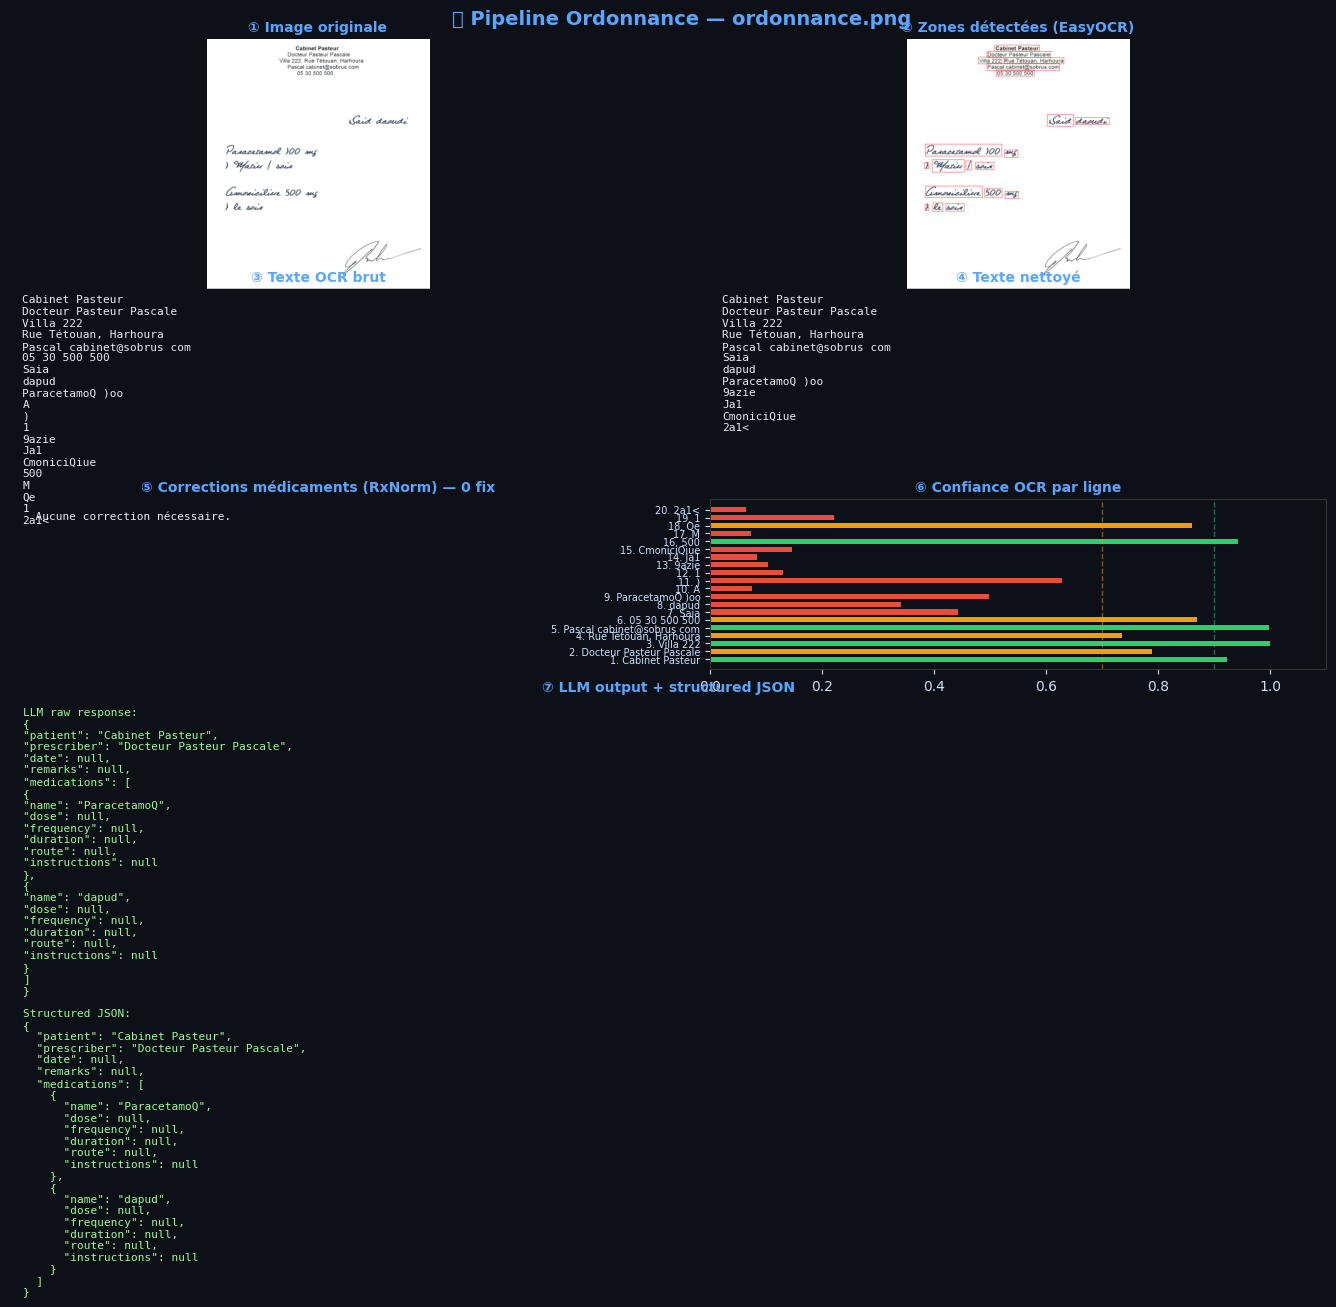

In [75]:
# ============================================================
# STEP 11 — TEST COMPLET
# ============================================================
#
# ➤ Modifie TEST_IMAGE_PATH avec le chemin de ton ordonnance
# ➤ Exécute cette cellule
# ============================================================

TEST_IMAGE_PATH = IMAGE_PATH   # ← Utilise l'image chargée en STEP 2
                               #   ou remplace par un autre chemin

# ── Pipeline complet ──────────────────────────────────────────
final_result = process_prescription(TEST_IMAGE_PATH)

# ── Affichage détaillé ────────────────────────────────────────
print("\n" + "─"*55)
print("  RÉSULTATS DÉTAILLÉS PAR ÉTAPE")
print("─"*55)

print("\n📝 [OCR BRUT]")
print(final_result['raw_text'])

print("\n🧹 [TEXTE NETTOYÉ]")
print(final_result['cleaned_text'])

print("\n💊 [CORRECTIONS MÉDICAMENTS]")
display_corrections(final_result['corrections'])

print("\n🤖 [LLM RAW RESPONSE]")
print(final_result.get('llm_response') or 'N/A')

print("\n📊 [RÉSULTAT STRUCTURÉ]")
if final_result['structured']:
    display_structured_result(final_result['structured'])
    print("\n📋 JSON final exportable :")
    print(json.dumps(final_result['structured'], indent=2, ensure_ascii=False))

    # Optionnel : sauvegarder le JSON dans un fichier
    output_json = "prescription_output.json"
    with open(output_json, 'w', encoding='utf-8') as f:
        json.dump(final_result['structured'], f, indent=2, ensure_ascii=False)
    print(f"\n💾 JSON sauvegardé : {output_json}")
else:
    print("⚠️  Pas de données structurées (Ollama requis pour cette étape).")

# ── Dashboard visuel ─────────────────────────────────────────
print("\n📊 Génération du dashboard...")
visualize_full_pipeline(final_result)

---

## 📌 Architecture recap

| Step | Tool | Role | Model/Source |
|-------|-------|------|-----------------|
| Detection | OCR model | Locate text blocks | Pretrained model |
| Recognition | OCR model | Read characters | Pretrained model |
| Correction | RapidFuzz + RxNorm | Fix OCR errors in names | NIH database |
| Structuring | Ollama / llama3 | Understand context and structure | Local LLM |

**No training.** All models are used in inference only.